In [1]:
from matplotlib import pyplot as plt
from PIL import ImageFont
import time
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import TensorBoard

จับท่าทางและมือ

In [2]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import cv2

class MediapipeTasksDetector:
    def __init__(self):
        BaseOptions = python.BaseOptions
        
        # 🔥 1. Pose: เปิด Tracking และตั้งค่าความมั่นใจ 0.7
        pose_options = vision.PoseLandmarkerOptions(
            base_options=BaseOptions(model_asset_path='pose_landmarker_full.task'),
            running_mode=vision.RunningMode.VIDEO, 
            min_pose_detection_confidence=0.6,
            min_pose_presence_confidence=0.6,
            min_tracking_confidence=0.6)
        self.pose_landmarker = vision.PoseLandmarker.create_from_options(pose_options)

        # 🔥 2. Hands: ตั้งค่าให้เกาะติดมือหนึบที่สุด (กันจุดกระพริบ)
        hand_options = vision.HandLandmarkerOptions(
            base_options=BaseOptions(model_asset_path='hand_landmarker.task'),
            running_mode=vision.RunningMode.VIDEO,
            num_hands=2,
            min_hand_detection_confidence=0.6,
            min_hand_presence_confidence=0.6,
            min_tracking_confidence=0.6)
        self.hand_landmarker = vision.HandLandmarker.create_from_options(hand_options)

        # 🔥 3. Face
        face_options = vision.FaceLandmarkerOptions(
            base_options=BaseOptions(model_asset_path='face_landmarker.task'),
            running_mode=vision.RunningMode.VIDEO,
            min_face_detection_confidence=0.6,
            min_face_presence_confidence=0.6,
            min_tracking_confidence=0.6)
        self.face_landmarker = vision.FaceLandmarker.create_from_options(face_options)
        
        # ตัวจัดการ Timestamp ที่ปลอดภัยที่สุดสำหรับการรันลูปความเร็วสูง
        self.internal_timestamp_ms = 0

    def detect(self, frame):
        # 1. แปลงสีภาพให้ตรงกับที่ MediaPipe ต้องการ (RGB)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        
        # 2. อัปเดต Timestamp ให้เดินหน้าเสมอ (MediaPipe บังคับว่าเวลาต้องเพิ่มขึ้นห้ามย้อนกลับ)
        self.internal_timestamp_ms += 33 
        
        # 3. สั่งรันโมเดลด้วยโหมด Video เพื่อดึงความสามารถ Tracking ออกมา
        pose_res = self.pose_landmarker.detect_for_video(mp_image, self.internal_timestamp_ms)
        hand_res = self.hand_landmarker.detect_for_video(mp_image, self.internal_timestamp_ms)
        face_res = self.face_landmarker.detect_for_video(mp_image, self.internal_timestamp_ms)
        
        return pose_res, face_res, hand_res

    def close(self):
        # 🔥 ฟังก์ชันคืนหน่วยความจำ: สำคัญมากเวลาสกัดวิดีโอหลักพันคลิป ป้องกันแรมเต็ม (Out of Memory)
        self.pose_landmarker.close()
        self.hand_landmarker.close()
        self.face_landmarker.close()

In [4]:
import numpy as np

FACE_KEY_POINTS = [
    70, 63, 105, 66, 107, 336, 296, 334, 293, 300,
    159, 145, 33, 133, 386, 374, 362, 263,
    1, 2, 98, 327, 13, 14, 17, 18
]

def extract_keypoints(pose_res, face_res, hand_res):
    pose = np.zeros((33, 4))
    face = np.zeros((26, 3))
    lh = np.zeros((21, 3))
    rh = np.zeros((21, 3))

    has_pose = len(pose_res.pose_landmarks) > 0
    has_face = len(face_res.face_landmarks) > 0

    if has_pose:
        for i, lm in enumerate(pose_res.pose_landmarks[0]):
            pose[i] = [lm.x, lm.y, lm.z, lm.visibility]

    if has_face:
        # ดึงเฉพาะจุดที่กำหนด 26 จุด
        for i, idx in enumerate(FACE_KEY_POINTS):
            lm = face_res.face_landmarks[0][idx]
            face[i] = [lm.x, lm.y, lm.z]

    has_lh, has_rh = False, False
    if len(hand_res.hand_landmarks) > 0:
        for i, handedness in enumerate(hand_res.handedness):
            category = handedness[0].category_name
            if category == "Left":
                has_lh = True
                for j, lm in enumerate(hand_res.hand_landmarks[i]):
                    lh[j] = [lm.x, lm.y, lm.z]
            elif category == "Right":
                has_rh = True
                for j, lm in enumerate(hand_res.hand_landmarks[i]):
                    rh[j] = [lm.x, lm.y, lm.z]

    pose_xyz = pose[:, :3]

    if has_pose:
        left_shoulder, right_shoulder = pose_xyz[11], pose_xyz[12]
        center = (left_shoulder + right_shoulder) / 2.0
        left_hip, right_hip = pose_xyz[23], pose_xyz[24]
        mid_hip = (left_hip + right_hip) / 2.0

        # 🔥 1. ใช้สูตร Scale แบบ Max เพื่อแก้ปัญหาไหล่เบี้ยว (ที่เป็นสาเหตุให้ทาย "เหนื่อย")
        torso_length = np.linalg.norm(center - mid_hip)
        shoulder_width = np.linalg.norm(left_shoulder - right_shoulder)
        scale = max(torso_length, shoulder_width)
        if scale < 0.05: scale = 1.0
    else:
        center = np.array([0.5, 0.5, 0.0])
        scale = 1.0

    # 2. Normalize พิกัดปกติ
    if has_pose: pose_xyz = (pose_xyz - center) / scale
    if has_face: face = (face - center) / scale
    if has_lh: lh = (lh - center) / scale
    if has_rh: rh = (rh - center) / scale

    # 🔥 3. เพิ่ม Spatial Helper (8 Features ใหม่)
    nose = pose_xyz[0]
    neck = np.array([0, 0, 0]) # จุดกึ่งกลางไหล่คือ 0,0,0 หลัง normalize
    
    # คำนวณระยะห่าง (Euclidean)
    d_rh_nose = np.linalg.norm(rh[8] - nose) if has_rh else 1.0
    d_lh_nose = np.linalg.norm(lh[8] - nose) if has_lh else 1.0
    d_rh_neck = np.linalg.norm(rh[8] - neck) if has_rh else 1.0
    d_lh_neck = np.linalg.norm(lh[8] - neck) if has_lh else 1.0
    
    # คำนวณระยะห่างแนวดิ่ง (แกน Y) - ตัวตัดสิน "ปวดหัว" (มือต้องสูงกว่าไหล่/จมูก)
    y_rh_nose = rh[8][1] - nose[1] if has_rh else 0.0
    y_lh_nose = lh[8][1] - nose[1] if has_lh else 0.0
    
    # ระยะห่างระหว่างมือสองข้าง
    d_hands = np.linalg.norm(rh[8] - lh[8]) if (has_rh and has_lh) else 1.0
    
    # ความเร็วหรือความมั่นใจ (ใช้ Visibility ของ Pose เป็นตัวแถม)
    pose_vis_avg = np.mean(pose[:, 3])

    spatial_features = np.array([
        d_rh_nose, d_lh_nose, d_rh_neck, d_lh_neck, 
        y_rh_nose, y_lh_nose, d_hands, pose_vis_avg
    ])

    # 4. รวมร่างข้อมูล (336 + 8 = 344)
    pose_final = np.concatenate([pose_xyz, pose[:, 3].reshape(-1, 1)], axis=1)
    keypoints = np.concatenate([
        pose_final.flatten(), 
        face.flatten(), 
        lh.flatten(), 
        rh.flatten(),
        spatial_features
    ])
    
    # ตรวจสอบขนาดให้เป๊ะ
    assert keypoints.shape[0] == 344, f"Shape error: {keypoints.shape}"
    return keypoints

จัดการโฟร์เดอร์และคำศัพท์

In [5]:
import os
import glob

VIDEO_PATH = "Sickness_data"    # โฟลเดอร์ใหญ่ต้นทางที่เก็บวิดีโอ

# ==========================================
# 🌟 ส่วนที่ 1: จัดการชื่อท่าทางอัตโนมัติ (Dynamic Classes)
# ==========================================
if not os.path.exists(VIDEO_PATH):
    print(f"❌ ไม่พบโฟลเดอร์ '{VIDEO_PATH}' กรุณาสร้างและใส่วิดีโอลงไปก่อน")
    actions = []
else:
    # ดึงเฉพาะ 'โฟลเดอร์' และตัดไฟล์ขยะทิ้ง
    actions = [d for d in os.listdir(VIDEO_PATH) if os.path.isdir(os.path.join(VIDEO_PATH, d))]
    # 🔥 บังคับเรียงตามตัวอักษร เพื่อให้ Index ของคลาสไม่สลับกันเวลาเทรน
    actions.sort() 

print(f"📂 พบหมวดหมู่ท่าทางทั้งหมด {len(actions)} ท่า ได้แก่: {actions}\n")

# ==========================================
# 🌟 ส่วนที่ 2: ค้นหาและนับจำนวนวิดีโอ (ดึงไฟล์อย่างเดียว)
# ==========================================
videos = {}

for action in actions:
    # ค้นหาวิดีโอทั้งหมดในโฟลเดอร์ของแต่ละท่า
    search_path = os.path.join(VIDEO_PATH, action, "*.*")
    video_list = glob.glob(search_path)
    videos[action] = video_list
    
    print(f"✅ หมวดหมู่ '{action}' พบวิดีโอทั้งหมด: {len(video_list)} คลิป")


📂 พบหมวดหมู่ท่าทางทั้งหมด 21 ท่า ได้แก่: ['คลื่นไส้', 'คันตา', 'ท้องเสีย', 'ปวดตา', 'ปวดท้อง', 'ปวดฟัน', 'ปวดหลัง', 'ปวดหัว', 'มีผื่น', 'ยืนนิ่ง', 'หนาวสั่น', 'หายใจไม่ออก', 'อาเจียน', 'เจ็บคอ', 'เจ็บหน้าอก', 'เจ็บแผล', 'เป็นแผล', 'เป็นไข้', 'เวียนหัว', 'เหนื่อย', 'ไอ']

✅ หมวดหมู่ 'คลื่นไส้' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'คันตา' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'ท้องเสีย' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'ปวดตา' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'ปวดท้อง' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'ปวดฟัน' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'ปวดหลัง' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'ปวดหัว' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'มีผื่น' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'ยืนนิ่ง' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'หนาวสั่น' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'หายใจไม่ออก' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'อาเจียน' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'เจ็บคอ' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'เจ็บหน้าอก' พบวิดีโอทั้งหมด: 14 คลิป
✅ หมวดหมู่ 'เจ็บแผล' พบวิดีโอทั้งหมด

ฟรอนตัวอักษรภาษาไทย

In [6]:
from PIL import ImageFont, ImageDraw, Image

fontpath = "./fonts/THSarabunNew.ttf" 
try:
    thai_font = ImageFont.truetype(fontpath, 32)
    print("✅ โหลดฟอนต์ THSarabunNew.ttf สำเร็จ")
except IOError:
    print(f"❌ ไม่พบฟอนต์ที่: {fontpath} จะใช้ฟอนต์เริ่มต้นแทน")
    thai_font = None 

def put_text_thai(img, text, org, color, font_size, font=thai_font):
    if font is None:
        cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, font_size/32, color, 2, cv2.LINE_AA)
        return img

    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)

    draw.text(org, text, font=font, fill=color)

    img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    return img_cv

✅ โหลดฟอนต์ THSarabunNew.ttf สำเร็จ


เก็บข้อมูลท่าทาง

In [7]:
def collect_data_from_video(detector, video_path, action, seq_len, data_path, start_seq=0):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return start_seq

    frames = []
    print(f"\n🎬 กำลังประมวลผล: {video_path}")

    while True:
        ret, frame = cap.read()
        if not ret: break

        h, w = frame.shape[:2]
        if w > h:
            frame = cv2.rotate(frame, cv2.ROTATE_90_CLOCKWISE)

        pose_res, face_res, hand_res = detector.detect(frame)
        
        # 🌟 ป้องกันเฟรมว่างเปล่า: ถ้ามองไม่เห็นโครงสร้างร่างกายคน ให้ข้ามเฟรมนี้ไปเลย ห้ามเก็บ!
        if not pose_res.pose_landmarks:
            continue

        keypoints = extract_keypoints(pose_res, face_res, hand_res)

        if keypoints.shape[0] == 344:
            frames.append(keypoints)

    cap.release()
    if len(frames) < seq_len: return start_seq

    stride = 5
    seq_count = start_seq
    for i in range(0, len(frames) - seq_len + 1, stride):
        window = frames[i:i+seq_len]
        save_path = os.path.join(data_path, action, str(seq_count))
        os.makedirs(save_path, exist_ok=True)
        for j, frame_data in enumerate(window):
            np.save(os.path.join(save_path, f"{j}.npy"), frame_data)
        seq_count += 1
    return seq_count

In [8]:
import os
import random
import shutil

DATA_PATH = "sickness"

# 🔥 ประกาศตัวเรียก MediaPipe ก่อนใช้งาน
detector = MediapipeTasksDetector()


print("\n--- เริ่ม extract จากวิดีโอ แบบแยก Train/Val (🔥 โหมดรันเฉพาะคำใหม่) ---")
SEQUENCE_LENGTH = 30

for action in actions:
    print(f"\n🔥 ACTION: {action}")
    
    # ==============================================================
    # 🎯 เช็คว่าโฟลเดอร์มีอยู่แล้วหรือยัง ถ้ามีให้ข้ามเลย!
    # ==============================================================
    check_path = os.path.join(DATA_PATH, "train", action)
    if os.path.exists(check_path):
        print(f"⏩ มีโฟลเดอร์ข้อมูลท่า '{action}' อยู่แล้ว -> ข้ามการดึงข้อมูล!")
        continue  # เตะออกไปทำรอบใหม่ (ท่าถัดไป) ทันที
    # ==============================================================

    vids = videos[action].copy()
    random.seed(42)
    random.shuffle(vids) # สลับลำดับคลิปวิดีโอ

    # แบ่งคลิป 80% (Train) และ 20% (Validation/ห้องสอบ)
    split_idx = int(len(vids) * 0.8)
    train_vids = vids[:split_idx]
    val_vids = vids[split_idx:]

    # --- 1. สกัดข้อมูลชุด Train ---
    train_action_path = os.path.join(DATA_PATH, "train", action)
    os.makedirs(train_action_path, exist_ok=True)
    
    # 🟢 บังคับเริ่มที่ 0 เสมอ สำหรับคำใหม่
    seq_start = 0 
    print(f"📁 [Train] สร้างข้อมูลใหม่ เริ่มเซฟที่ลำดับ: {seq_start}")
    
    for video_path in train_vids:
        seq_start = collect_data_from_video(
            detector, video_path, action, SEQUENCE_LENGTH,
            os.path.join(DATA_PATH, "train"), start_seq=seq_start
        )

    # --- 2. สกัดข้อมูลชุด Validation ---
    val_action_path = os.path.join(DATA_PATH, "val", action)
    os.makedirs(val_action_path, exist_ok=True)
    
    # 🟢 บังคับเริ่มที่ 0 เสมอ สำหรับคำใหม่
    seq_start = 0 
    print(f"📁 [Val] สร้างข้อมูลใหม่ เริ่มเซฟที่ลำดับ: {seq_start}")
    
    for video_path in val_vids:
        seq_start = collect_data_from_video(
            detector, video_path, action, SEQUENCE_LENGTH,
            os.path.join(DATA_PATH, "val"), start_seq=seq_start
        )

# คืน Memory ให้คอมพิวเตอร์
detector.close()
print("\n✅ อัปเดตข้อมูลใหม่เสร็จสมบูรณ์!")


--- เริ่ม extract จากวิดีโอ แบบแยก Train/Val (🔥 โหมดรันเฉพาะคำใหม่) ---

🔥 ACTION: คลื่นไส้
⏩ มีโฟลเดอร์ข้อมูลท่า 'คลื่นไส้' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: คันตา
⏩ มีโฟลเดอร์ข้อมูลท่า 'คันตา' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: ท้องเสีย
⏩ มีโฟลเดอร์ข้อมูลท่า 'ท้องเสีย' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: ปวดตา
⏩ มีโฟลเดอร์ข้อมูลท่า 'ปวดตา' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: ปวดท้อง
⏩ มีโฟลเดอร์ข้อมูลท่า 'ปวดท้อง' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: ปวดฟัน
⏩ มีโฟลเดอร์ข้อมูลท่า 'ปวดฟัน' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: ปวดหลัง
⏩ มีโฟลเดอร์ข้อมูลท่า 'ปวดหลัง' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: ปวดหัว
⏩ มีโฟลเดอร์ข้อมูลท่า 'ปวดหัว' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: มีผื่น
⏩ มีโฟลเดอร์ข้อมูลท่า 'มีผื่น' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: ยืนนิ่ง
⏩ มีโฟลเดอร์ข้อมูลท่า 'ยืนนิ่ง' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: หนาวสั่น
⏩ มีโฟลเดอร์ข้อมูลท่า 'หนาวสั่น' อยู่แล้ว -> ข้ามการดึงข้อมูล!

🔥 ACTION: หายใจไม่ออก
⏩ มีโฟลเดอร์ข้อมูลท่า

การเตรียมข้อมูลสำหรับนำไปเทรน

In [9]:
import os
import numpy as np
from tensorflow.keras.utils import to_categorical

SEQUENCE_LENGTH = 30

def load_data_from_folder(base_path):
    sequences, labels = [], []
    for action_index, action in enumerate(actions):
        action_path = os.path.join(base_path, action)
        if not os.path.exists(action_path): continue

        sequence_folders = sorted([d for d in os.listdir(action_path) if d.isdigit()], key=int)
        for seq_folder in sequence_folders:
            seq_path = os.path.join(action_path, seq_folder)
            window = []
            for frame_m in range(SEQUENCE_LENGTH):
                try:
                    res = np.load(os.path.join(seq_path, f'{frame_m}.npy'))
                    window.append(res)
                except:
                    window = []
                    break
            if len(window) == SEQUENCE_LENGTH:
                sequences.append(window)
                labels.append(action_index)
    
    if len(sequences) == 0:
        return np.array([]), np.array([])
    return np.array(sequences).astype(np.float32), to_categorical(labels, num_classes=len(actions)).astype(np.float32)

print("--- โหลดข้อมูลชุด Train ---")
X_train_raw, y_train_raw = load_data_from_folder(os.path.join(DATA_PATH, "train"))
print("--- โหลดข้อมูลชุด Validation ---")
X_val, y_val = load_data_from_folder(os.path.join(DATA_PATH, "val"))

print(f"\n📊 Sequences ชุด Train ก่อนปรับสมดุล: {np.sum(y_train_raw, axis=0)}")

# --- ทำ Undersampling ให้ชุด Train ---
min_samples = int(np.min(np.sum(y_train_raw, axis=0)))
print(f"⚖️ กำลังปรับลดชุด Train ให้ทุกคลาสมีเท่ากันที่: {min_samples} Sequences")

balanced_X, balanced_y = [], []
for i in range(len(actions)):
    idx = np.where(np.argmax(y_train_raw, axis=1) == i)[0]
    selected_idx = np.random.choice(idx, min_samples, replace=False)
    balanced_X.extend(X_train_raw[selected_idx])
    balanced_y.extend(y_train_raw[selected_idx])

X_train2 = np.array(balanced_X)
y_train2 = np.array(balanced_y)

print(f"✅ ขนาด X_train (หลังปรับสมดุล): {X_train2.shape}")
print(f"✅ ขนาด X_val (ห้องสอบของจริง): {X_val.shape}")

--- โหลดข้อมูลชุด Train ---
--- โหลดข้อมูลชุด Validation ---

📊 Sequences ชุด Train ก่อนปรับสมดุล: [280. 260. 270. 277. 291. 279. 261. 313. 297. 282. 279. 339. 285. 284.
 283. 287. 282. 270. 267. 297. 287.]
⚖️ กำลังปรับลดชุด Train ให้ทุกคลาสมีเท่ากันที่: 260 Sequences
✅ ขนาด X_train (หลังปรับสมดุล): (5460, 30, 344)
✅ ขนาด X_val (ห้องสอบของจริง): (1583, 30, 344)


In [10]:
import numpy as np
from sklearn.utils import shuffle

def safe_smart_augment(data):
    augmented_data = np.copy(data)
    num_samples = data.shape[0]
    
    # ==========================================
    # 1. Scale (ย่อ/ขยาย): ปรับช่วงให้ปลอดภัยขึ้น (95% - 105%)
    # ==========================================
    # เพื่อป้องกันไม่ให้มือที่อยู่ใกล้หน้าขยับห่างออกไปมากเกินจน AI ผิดสังเกต
    scales = np.random.uniform(0.95, 1.05, size=(num_samples, 1, 1))
    augmented_data = augmented_data * scales
    
    # ==========================================
    # 2. Shift (เลื่อนซ้ายขวา/บนล่าง): ขยับเฉพาะ X และ Y
    # ==========================================
    # เตรียม Index ของพิกัด X และ Y เพื่อไม่ให้กระทบแกน Z และ Visibility
    # Pose (132 ค่าแรก, รูปแบบ x,y,z,v) -> X เริ่ม 0 ขยับทีละ 4 / Y เริ่ม 1 ขยับทีละ 4
    pose_x = list(range(0, 132, 4))
    pose_y = list(range(1, 132, 4))
    
    # Face (78 ค่าต่อมา, รูปแบบ x,y,z)
    face_x = list(range(132, 210, 3))
    face_y = list(range(133, 210, 3))
    
    # Left Hand (63 ค่า, รูปแบบ x,y,z)
    lh_x = list(range(210, 273, 3))
    lh_y = list(range(211, 273, 3))
    
    # Right Hand (63 ค่า, รูปแบบ x,y,z)
    rh_x = list(range(273, 336, 3))
    rh_y = list(range(274, 336, 3))
    
    # รวม Index ของ X และ Y ทั้งหมด
    idx_x = pose_x + face_x + lh_x + rh_x
    idx_y = pose_y + face_y + lh_y + rh_y
    
    # สุ่มค่าเลื่อน ซ้าย-ขวา (X) และ บน-ล่าง (Y) "แยกอิสระจากกัน" (ไม่เกิน 3% ของหน้าจอ)
    shift_x = np.random.uniform(-0.03, 0.03, size=(num_samples, 1, 1))
    shift_y = np.random.uniform(-0.03, 0.03, size=(num_samples, 1, 1))
    
    # บวกค่า Shift เข้าไปเฉพาะแกนที่ถูกต้อง (กระดูกไม่หัก และ Z/Visibility ไม่เพี้ยน)
    augmented_data[:, :, idx_x] += shift_x
    augmented_data[:, :, idx_y] += shift_y
    
    return augmented_data

print("🔥 กำลังสร้างร่างโคลนข้อมูลด้วย Safe Smart Augmentation...")
X_train_smart_aug = safe_smart_augment(X_train2)

# นำข้อมูล Train เดิม มาต่อกับข้อมูลที่ปั๊มใหม่ (เพิ่มขึ้น 2 เท่า)
X_train_augmented = np.concatenate((X_train2, X_train_smart_aug), axis=0)
y_train_augmented = np.concatenate((y_train2, y_train2), axis=0)

# สลับข้อมูล (Shuffle) 
X_train_augmented, y_train_augmented = shuffle(X_train_augmented, y_train_augmented, random_state=42)

print(f"✅ ปริมาณข้อมูล Train พร้อมเทรน: {X_train_augmented.shape[0]} คลิป")
print(f"📊 ปริมาณข้อมูล Validation (ห้องสอบเดิม ไม่โดน Augment): {X_val.shape[0]} คลิป")

🔥 กำลังสร้างร่างโคลนข้อมูลด้วย Safe Smart Augmentation...
✅ ปริมาณข้อมูล Train พร้อมเทรน: 10920 คลิป
📊 ปริมาณข้อมูล Validation (ห้องสอบเดิม ไม่โดน Augment): 1583 คลิป


โมเดลสำหรับเทรนข้อมูล

In [ ]:
from tensorflow.keras.layers import Layer, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# กำหนด Layer เองสำหรับ Transformer
class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        
        # 🔥 แก้ไขจุดที่ 1: เปลี่ยน Dropout(0.3) เป็น Dropout(rate) เพื่อให้ใช้ตัวแปรแบบไดนามิก
        self.ffn = Sequential([
            Dense(ff_dim, activation="relu"),
            Dropout(rate), 
            Dense(embed_dim)
        ])
        
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate

    def call(self, inputs, training=None):
        # Multi-Head Attention
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        # Feed Forward Network
        ffn_output = self.ffn(out1, training=training) 
        ffn_output = self.dropout2(ffn_output, training=training)
        
        return self.layernorm2(out1 + ffn_output)
    
    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "num_heads": self.num_heads, "ff_dim": self.ff_dim, "rate": self.rate,})
        return config

class PositionalEmbedding(Layer):
    def __init__(self, sequence_length, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = Dense(embed_dim) 
        self.position_embeddings = tf.keras.layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.embed_dim = embed_dim

    def call(self, inputs):
        length = tf.shape(inputs)[1]
        positions = tf.range(start=0, limit=length, delta=1)
        position_embedding = self.position_embeddings(positions)
        token_embedding = self.token_embeddings(inputs)
        return token_embedding + position_embedding
    
    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "embed_dim": self.embed_dim,})
        return config

# กำหนด Hyperparameters และสร้างโมเดล
embed_dim = 128
num_heads = 4
ff_dim = 128
NUM_KEYPOINTS = 344
input_shape = (SEQUENCE_LENGTH, NUM_KEYPOINTS) 
num_classes = y_train_augmented.shape[1] # 🔥 (อย่าลืมเช็คว่าใช้ y_train หรือ y_train_augmented )

def create_transformer_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    x = PositionalEmbedding(SEQUENCE_LENGTH, embed_dim)(inputs)
    x = Dropout(0.3)(x) 
    x = LayerNormalization(epsilon=1e-6)(x)
    
    # Transformer Encoder Blocks
    for _ in range(2):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, rate=0.3)(x)

    # Output Layers
    x = LayerNormalization(epsilon=1e-6)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation="relu", kernel_regularizer=l2(0.01))(x) 
    x = Dropout(0.3)(x) 
    outputs = Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

transformer_model = create_transformer_model(input_shape, num_classes)

print("\n--- โครงสร้างโมเดล Transformer ---")
transformer_model.summary()



--- โครงสร้างโมเดล Transformer ---


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 344)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 30, 128)        │        48,000 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 30, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 128)        │       297,344 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 30, 128)        │       297,344 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 30, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,421 (2.53 MB)

 Trainable params: 662,421 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 13. การฝึกฝนโมเดล (Anti-Overfit Version)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

EPOCHS = 500
BATCH_SIZE = 64

optimizer = Adam(
    learning_rate=1e-4,
    clipnorm=1.0
)

loss = tf.keras.losses.CategoricalCrossentropy()

transformer_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['categorical_accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',      
        patience=8, # 🔥 ลด Patience ลง ถ้ายิ่งเทรน loss ยิ่งเด้งขึ้น ให้หยุดเลย
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "sickness_Aug1.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

# 🔥 เปลี่ยน X_train2 เป็น X_train_augmented ที่เราปั๊มมา 2 เท่า
history = transformer_model.fit(
    X_train_augmented, 
    y_train_augmented, 
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/500
171/171 - 56s - 328ms/step - categorical_accuracy: 0.2329 - loss: 3.7053 - val_categorical_accuracy: 0.5925 - val_loss: 2.4770 - learning_rate: 1.0000e-04
Epoch 2/500
171/171 - 46s - 268ms/step - categorical_accuracy: 0.5351 - loss: 2.5791 - val_categorical_accuracy: 0.7208 - val_loss: 1.8718 - learning_rate: 1.0000e-04
Epoch 3/500
171/171 - 46s - 272ms/step - categorical_accuracy: 0.6853 - loss: 2.0254 - val_categorical_accuracy: 0.7934 - val_loss: 1.5987 - learning_rate: 1.0000e-04
Epoch 4/500
171/171 - 46s - 269ms/step - categorical_accuracy: 0.7785 - loss: 1.6863 - val_categorical_accuracy: 0.8351 - val_loss: 1.4188 - learning_rate: 1.0000e-04
Epoch 5/500
171/171 - 46s - 270ms/step - categorical_accuracy: 0.8303 - loss: 1.4500 - val_categorical_accuracy: 0.8648 - val_loss: 1.2808 - learning_rate: 1.0000e-04
Epoch 6/500
171/171 - 48s - 283ms/step - categorical_accuracy: 0.8764 - loss: 1.2605 - val_categorical_accuracy: 0.8515 - val_loss: 1.1926 - learning_rate: 1.0000e-0


--- 📊 ผลการประเมินโมเดลบนชุดข้อมูลห้องสอบ (Unseen Data) ---
✅ ความแม่นยำ (Validation Accuracy): 93.49%
📉 ค่าความผิดพลาด (Validation Loss): 0.3014

--- 📦 สรุปปริมาณข้อมูลที่ใช้เทรนรอบนี้ ---
Train (ข้อมูลห้องเรียน + ร่างโคลน): 10920 sequences
Val (ข้อมูลห้องสอบที่ AI ไม่เคยเห็น): 1583 sequences

--- 🎯 จำนวนข้อสอบแต่ละท่าในชุด Validation ---
ท่า 'คลื่นไส้': 73 sequences
ท่า 'คันตา': 70 sequences
ท่า 'ท้องเสีย': 73 sequences
ท่า 'ปวดตา': 72 sequences
ท่า 'ปวดท้อง': 74 sequences
ท่า 'ปวดฟัน': 75 sequences
ท่า 'ปวดหลัง': 67 sequences
ท่า 'ปวดหัว': 79 sequences
ท่า 'มีผื่น': 77 sequences
ท่า 'ยืนนิ่ง': 77 sequences
ท่า 'หนาวสั่น': 81 sequences
ท่า 'หายใจไม่ออก': 90 sequences
ท่า 'อาเจียน': 79 sequences
ท่า 'เจ็บคอ': 66 sequences
ท่า 'เจ็บหน้าอก': 73 sequences
ท่า 'เจ็บแผล': 82 sequences
ท่า 'เป็นแผล': 75 sequences
ท่า 'เป็นไข้': 73 sequences
ท่า 'เวียนหัว': 68 sequences
ท่า 'เหนื่อย': 81 sequences
ท่า 'ไอ': 78 sequences


C:\Users\HP\AppData\Local\Temp\ipykernel_18304\1103046188.py:50: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_18304\1103046188.py:50: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_18304\1103046188.py:50: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_18304\1103046188.py:50: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_18304\1103046188.py:50: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_18304\1103046188.py:50: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) 

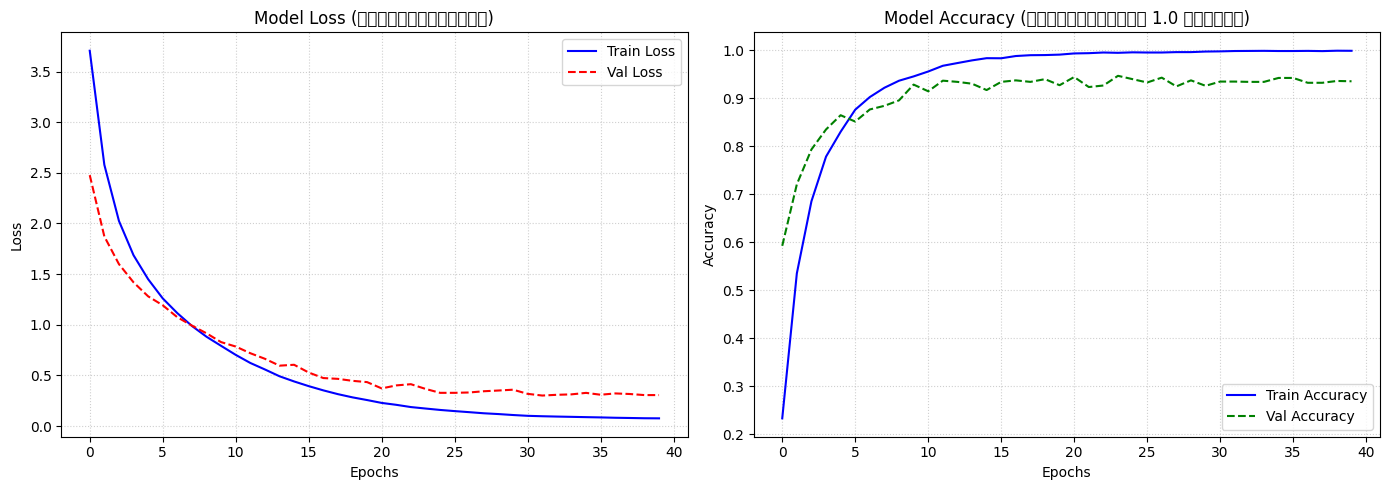

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. ประเมินผลด้วยชุด Validation (ห้องสอบของเรา)
# ==========================================
print("\n--- 📊 ผลการประเมินโมเดลบนชุดข้อมูลห้องสอบ (Unseen Data) ---")
val_loss, val_acc = transformer_model.evaluate(X_val, y_val, verbose=0)
print(f"✅ ความแม่นยำ (Validation Accuracy): {val_acc * 100:.2f}%")
print(f"📉 ค่าความผิดพลาด (Validation Loss): {val_loss:.4f}")

# ==========================================
# 2. สรุปปริมาณข้อมูลที่ใช้ในระบบปัจจุบัน
# ==========================================
print("\n--- 📦 สรุปปริมาณข้อมูลที่ใช้เทรนรอบนี้ ---")
print(f"Train (ข้อมูลห้องเรียน + ร่างโคลน): {len(X_train_augmented)} sequences")
print(f"Val (ข้อมูลห้องสอบที่ AI ไม่เคยเห็น): {len(X_val)} sequences")

# ==========================================
# 3. เช็คการกระจายตัวของข้อสอบในชุด Validation
# ==========================================
print("\n--- 🎯 จำนวนข้อสอบแต่ละท่าในชุด Validation ---")
val_distribution = np.sum(y_val, axis=0)
for i, count in enumerate(val_distribution):
    print(f"ท่า '{actions[i]}': {int(count)} sequences")

# ==========================================
# 4. วาดกราฟวิเคราะห์การเรียนรู้ของ AI (Learning Curve)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📉 กราฟที่ 1: ดูค่าความผิดพลาด (Loss) 
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='red', linestyle='--')
axes[0].set_title('Model Loss (ยิ่งต่ำยิ่งดี)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# 📈 กราฟที่ 2: ดูค่าความแม่นยำ (Accuracy)
axes[1].plot(history.history['categorical_accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_categorical_accuracy'], label='Val Accuracy', color='green', linestyle='--')
axes[1].set_title('Model Accuracy (ยิ่งเข้าใกล้ 1.0 ยิ่งดี)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

✅ โหลดฟอนต์สำหรับตารางสำเร็จ

กำลังประมวลผลข้อสอบเพื่อสร้างตาราง Confusion Matrix...
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


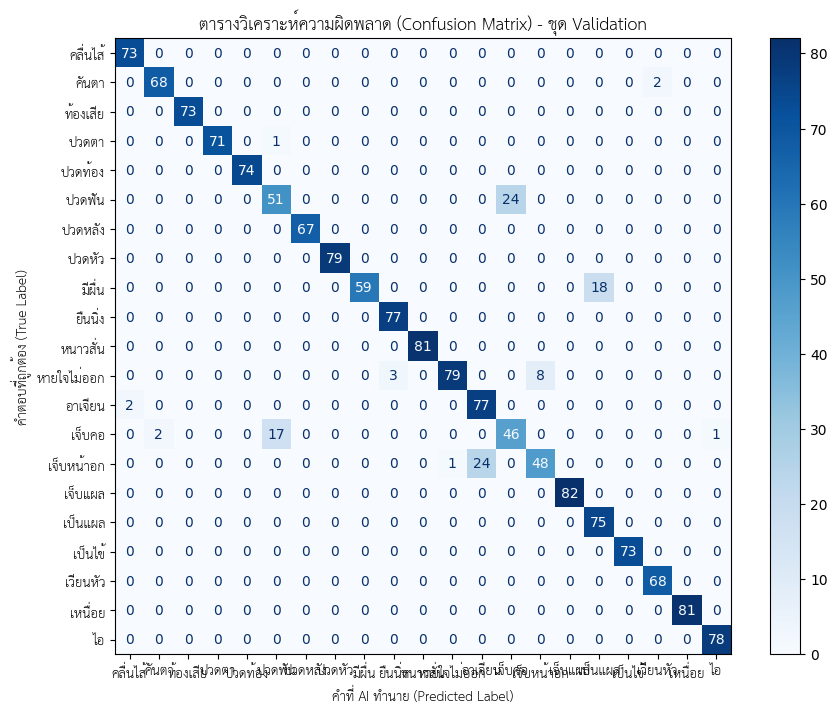


--- 📊 รายงานประสิทธิภาพเชิงลึก (Classification Report) ---
              precision    recall  f1-score   support

    คลื่นไส้       0.97      1.00      0.99        73
       คันตา       0.97      0.97      0.97        70
    ท้องเสีย       1.00      1.00      1.00        73
       ปวดตา       1.00      0.99      0.99        72
     ปวดท้อง       1.00      1.00      1.00        74
      ปวดฟัน       0.74      0.68      0.71        75
     ปวดหลัง       1.00      1.00      1.00        67
      ปวดหัว       1.00      1.00      1.00        79
      มีผื่น       1.00      0.77      0.87        77
     ยืนนิ่ง       0.96      1.00      0.98        77
    หนาวสั่น       1.00      1.00      1.00        81
 หายใจไม่ออก       0.99      0.88      0.93        90
     อาเจียน       0.76      0.97      0.86        79
      เจ็บคอ       0.66      0.70      0.68        66
  เจ็บหน้าอก       0.86      0.66      0.74        73
     เจ็บแผล       1.00      1.00      1.00        82
     เป็นแผล       0.

In [14]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 1. ตั้งค่าฟอนต์ภาษาไทย
# ใช้พาธเดียวกับที่คุณโหลดในโค้ดส่วนที่ 8 ของคุณ
font_path = "./fonts/THSarabunNew.ttf" 
try:
    thai_font = font_manager.FontProperties(fname=font_path, size=14)
    header_font = font_manager.FontProperties(fname=font_path, size=18)
    print("✅ โหลดฟอนต์สำหรับตารางสำเร็จ")
except:
    print("❌ ไม่พบฟอนต์ไทย ตารางอาจแสดงผลผิดพลาด")

# 2. ทำนายผลจากชุดข้อมูลห้องสอบ (Validation Set)
print("\nกำลังประมวลผลข้อสอบเพื่อสร้างตาราง Confusion Matrix...")
y_pred = transformer_model.predict(X_val)  # 🔥 เปลี่ยนจาก X_test เป็น X_val
y_true = np.argmax(y_val, axis=1)          # 🔥 เปลี่ยนจาก y_test เป็น y_val
y_pred_classes = np.argmax(y_pred, axis=1)

# 3. คำนวณ Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 4. วาดตารางด้วย ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=actions)

# แสดงผลโดยใช้สี Blues และวาดลงบน ax ที่เตรียมไว้
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

# --- ส่วนสำคัญ: ตั้งค่าภาษาไทยให้แต่ละจุดของกราฟ ---

# ปรับฟอนต์ที่แกน X (คำที่ทำนาย)
for label in ax.get_xticklabels():
    label.set_fontproperties(thai_font)

# ปรับฟอนต์ที่แกน Y (คำตอบจริง)
for label in ax.get_yticklabels():
    label.set_fontproperties(thai_font)

# ปรับฟอนต์หัวข้อและชื่อแกน
ax.set_title('ตารางวิเคราะห์ความผิดพลาด (Confusion Matrix) - ชุด Validation', fontproperties=header_font)
ax.set_xlabel('คำที่ AI ทำนาย (Predicted Label)', fontproperties=thai_font)
ax.set_ylabel('คำตอบที่ถูกต้อง (True Label)', fontproperties=thai_font)

plt.show()

# 5. แสดงรายงานตัวเลขสรุป
from sklearn.metrics import classification_report
print("\n--- 📊 รายงานประสิทธิภาพเชิงลึก (Classification Report) ---")
print(classification_report(y_true, y_pred_classes, target_names=actions))

In [ ]:
# model_save_path = 'lllnes_test_newmodel.keras'
# try:
#     transformer_model.save(model_save_path, save_format='keras')
#     print(f"✅ บันทึกโมเดลสำเร็จที่: {model_save_path}")
# except Exception as e:
#     print(f"❌ เกิดข้อผิดพลาดในการบันทึกโมเดล: {e}")

ทดสอบโมเดลที่เทรน

In [15]:
from tensorflow.keras.models import load_model

In [16]:
MODEL_PATH = 'sickness_Aug1.keras'
SEQUENCE_LENGTH = 30 # ความยาว Sequence ที่ใช้ในการฝึกฝน
THRESHOLD = 0.7 # เกณฑ์ความมั่นใจในการแสดงผล (Confidence Threshold)

# รายการคำศัพท์ที่ใช้ในการฝึกฝน (ต้องตรงกับที่ใช้ในการฝึกโมเดล)
ACTIONS = np.array([ 'คลื่นไส้', 'คันตา', 'ท้องเสีย', 'ปวดตา', 'ปวดท้อง', 'ปวดฟัน', 'ปวดหลัง', 'ปวดหัว', 'มีผื่น', 'ยืนนิ่ง', 'หนาวสั่น', 'หายใจไม่ออก', 'อาเจียน', 'เจ็บคอ', 'เจ็บหน้าอก', 'เจ็บแผล', 'เป็นแผล', 'เป็นไข้', 'เวียนหัว', 'เหนื่อย', 'ไอ']) 

In [17]:
custom_objects_dict = {
    'TransformerBlock': TransformerBlock,
    'PositionalEmbedding': PositionalEmbedding
}
try:
    model = load_model(MODEL_PATH, custom_objects=custom_objects_dict)
    print(f"✅ โหลดโมเดลสำเร็จจาก: {MODEL_PATH}")
except Exception as e:
    print(f"❌ ERROR: ไม่สามารถโหลดโมเดลได้ ตรวจสอบชื่อไฟล์และคลาส Custom: {e}")
    exit()

d:\Anaconda\envs\medisign_env\lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
d:\Anaconda\envs\medisign_env\lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
d:\Anaconda\envs\medisign_env\lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'tr

✅ โหลดโมเดลสำเร็จจาก: sickness_Aug1.keras


Convert to tflite

In [18]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model = load_model("sickness_Aug1.keras", custom_objects=custom_objects_dict)

# 2. สร้าง Converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# (Optional) Optimization: ลดขนาดไฟล์และทำให้ทำงานเร็วขึ้นบนมือถือ
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# 3. แปลงเป็น TFLite
tflite_model = converter.convert()

# 4. บันทึกเป็นไฟล์ใหม่
with open('sickness_best.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp8tbv5_fc\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp8tbv5_fc\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmp8tbv5_fc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 344), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 21), dtype=tf.float32, name=None)
Captures:
  2352893222000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2352893221824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2352893423360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2352893222352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2352893224816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2352893223056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2352893534880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2351723012768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2352893420192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2352893420016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  235289314764